In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split   
df=pd.read_csv(r'preprocessed_data.csv')
print(df.head())

   Employee_Id  Age  Experience_Years Education_Level  Job_Level Department  \
0            1   30                 6        Bachelor          2         HR   
1            2   40                19        Bachelor          5  Marketing   
2            3   39                14             PhD          4    Finance   
3            4   38                10          Master          4         IT   
4            5   34                 7        Bachelor          3         IT   

   Performance_Score  Weekly_Working_Hours  Salary_LPA  
0                  3                  43.1       18.71  
1                  8                  40.8       42.69  
2                  2                  44.8       39.37  
3                  4                  37.1       33.53  
4                  3                  48.5       25.56  


In [12]:
df.columns

Index(['Employee_Id', 'Age', 'Experience_Years', 'Education_Level',
       'Job_Level', 'Department', 'Performance_Score', 'Weekly_Working_Hours',
       'Salary_LPA'],
      dtype='str')

In [13]:
df.dtypes

Employee_Id               int64
Age                       int64
Experience_Years          int64
Education_Level             str
Job_Level                 int64
Department                  str
Performance_Score         int64
Weekly_Working_Hours    float64
Salary_LPA              float64
dtype: object

Intercept:  [-15.94057727]
Coefficients:  [[ 0.06261549  0.7970417   0.51676061  0.04132607  2.09870555  4.55800136
  -2.18023228 -0.5810653   2.0789095   2.10937827  0.34623983 -1.12387254
   1.28927579 -0.16943518 -1.11343459]]

Accuracy: 0.9833333333333333
Accuracy Percentage: 98.33333333333333 %

Actual vs Predicted Salary
   Experience_Years  Actual Salary_LPA  Actual Salary Class  \
0                 3              21.88                    0   
1                 7              31.46                    1   
2                16              42.23                    1   
3                 1              12.46                    0   
4                 4              22.57                    0   
5                 0              21.18                    0   
6                12              40.31                    1   
7                20              44.31                    1   
8                17              38.35                    1   
9                 3              18.56   

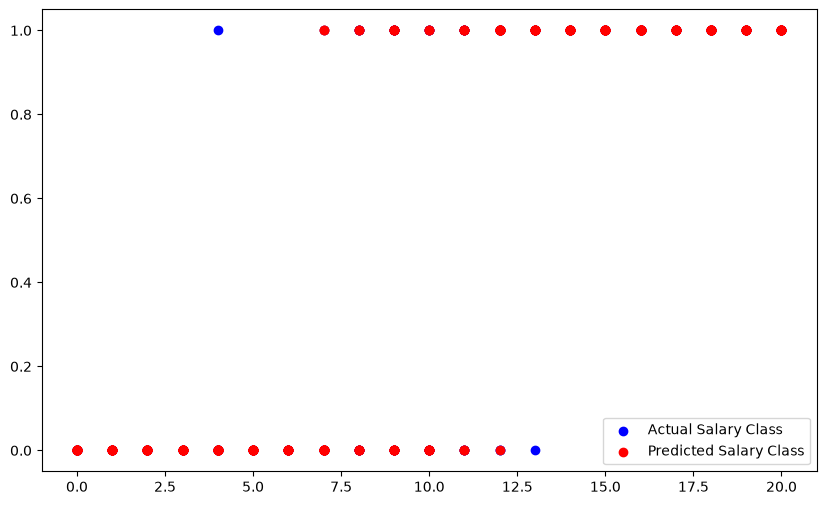

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df["Salary_Class"] = (
    df["Salary_LPA"] >= df["Salary_LPA"].median()
).astype(int)
X = df[
    [
        'Age',
        'Experience_Years',
        'Education_Level',
        'Job_Level',
        'Department',
        'Performance_Score',
        'Weekly_Working_Hours'
    ]
]

y = df['Salary_Class']
X = pd.get_dummies(
    X,
    columns=['Education_Level', 'Job_Level', 'Department'],
    drop_first=True
)
y = df["Salary_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

results = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Salary_LPA": df.loc[X_test.index, "Salary_LPA"].values,
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary")
print(results.head(10))

plt.figure(figsize=(10, 6))
plt.scatter(
    X_test["Experience_Years"],
    y_test,
    color="blue",
    label="Actual Salary Class"
)
plt.scatter(
    X_test["Experience_Years"],
    y_pred,
    color="red",
    label="Predicted Salary Class"
)
plt.xlabel = ("Experience_Years")
plt.ylabel = ("Salary Class")
plt.title = ("Actual vs Predicted Salary Class")
plt.legend()
plt.show()


In [15]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score , recall_score , precision_score

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)

Accuracy: 0.9833333333333333
Confusion matrix:  [[147   3]
 [  2 148]]
Classification_report:                precision    recall  f1-score   support

           0       0.99      0.98      0.98       150
           1       0.98      0.99      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

f1_score:  0.9833887043189369
recall_score: 0.9866666666666667
precision_score:  0.9801324503311258


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



mean_absolute_error = mean_absolute_error(y_test, y_pred)

mean_squared_error = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error ** 0.5

r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.016666666666666666
MSE : 0.016666666666666666
RMSE: 0.12909944487358055
R2 Score: 0.9333333333333333


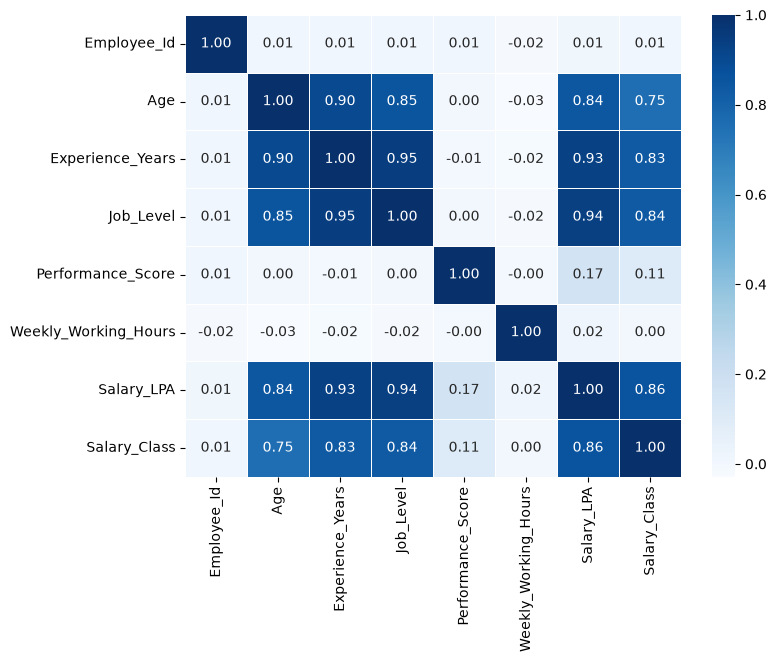

In [18]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title = ("correlation matrix")
plt.show()
